# Continual Learning (CL) 目标检测实验验证

**项目目录**: /yolov11/CL/ <br>
**任务类型** : 基于 YOLOv11n 的持续学习（多阶段增量训练）<br>
**目标**: 通过分阶段训练（Stage1 → Stage2 → Stage3），逐步适应新数据或新任务，同时避免灾难性遗忘（Catastrophic Forgetting）<br>
**阶段目标**：
- Stage1 学习圆环特征 （对比实验室环境，生成基础的预训练模型）
- Stage2 在Stage1的参数上继续训练，学习三角形特征（对比设备部署后生产环境，添加新类别进行微调模型）
- Stage3 在Stage2的参数上继续训练，学习矩形特征（对比设备部署后生产环境，添加新类别进行微调模型）


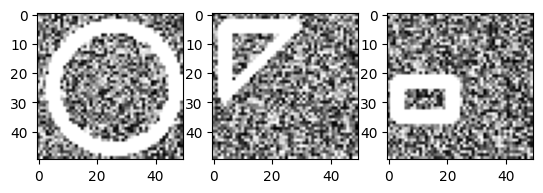

In [ ]:
# data 

In [ ]:
# model 参数
print(model.info()) 
print("""
Ultralytics 8.3.168 🚀 Python-3.9.23 torch-2.7.1+cu126 CUDA:0 (NVIDIA RTX 4060)
YOLO11n-CL summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 29.28it/s]
                   all          6          5       0.85      0.833      0.939      0.747
                  ring          1          1      0.719          1      0.995      0.895
              triangle          2          2      0.964          1      0.995      0.697
             rectangle          2          2      0.867        0.5      0.828      0.649
Speed: 0.1ms preprocess, 2.1ms inference, 0.0ms loss, 0.8ms postprocess per image
""")


YOLO11n-CL summary: 181 layers, 2,590,230 parameters, 0 gradients, 6.4 GFLOPs
(181, 2590230, 0, 6.4416768)

Ultralytics 8.3.168 🚀 Python-3.9.23 torch-2.7.1+cu126 CUDA:0 (NVIDIA RTX 4060)
YOLO11n-CL summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 29.28it/s]
                   all          6          5       0.85      0.833      0.939      0.747
                  ring          1          1      0.719          1      0.995      0.895
              triangle          2          2      0.964          1      0.995      0.697
             rectangle          2          2      0.867        0.5      0.828      0.649
Speed: 0.1ms preprocess, 2.1ms inference, 0.0ms loss, 0.8ms postprocess per image



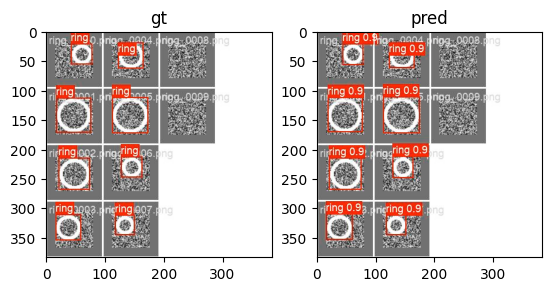

In [ ]:
# stage1

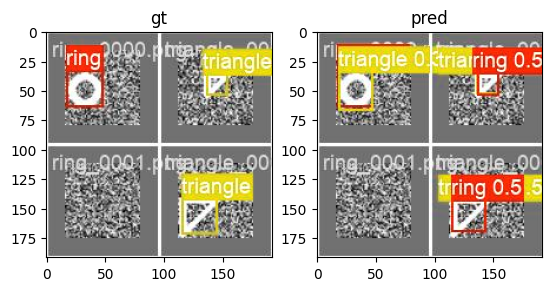

训练时间： 54.0542938709259  seconds


In [ ]:
# stage 2   54.05 seconds

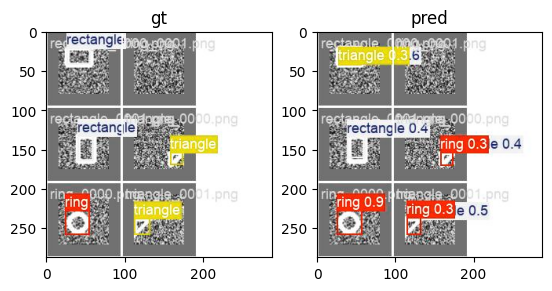

训练时间： 54.0542938709259  seconds


In [ ]:
# stage 3 54.05 seconds

---

## 1. 项目简介

本项目实现了一个 **基于 YOLOv11 的  Continual Learning（CL）目标检测实验**，  
目标是在 **不显著遗忘旧类别** 的前提下，**逐阶段引入新类别**，并验证：

- 新类别的学习能力
- 旧类别的保持能力
- 训练效率（快速收敛）

实验采用 **人工生成的几何形状数据集**，用于构建一个**可控、可复现、低噪声**的 CL benchmark。



## 2. 任务定义

### 2.1 学习范式

- **Class-Incremental Detection**
- 每一阶段：
  - 类别数增加
  - 模型参数继承上一阶段
  - 旧类别数据仅部分可见（Replay）

## 3. 数据集说明

### 3.1 数据特征

- 图像尺寸：`50 × 50`
- 灰度图（单通道）
- 背景：随机噪声 / 0 填充
- 目标形状：
  - ring（圆环）
  - triangle（三角形）
  - rectangle（矩形）
- 目标支持：
  - 填充（thickness = -1）
  - 轮廓（thickness ≥ 1）

### 3.2 数据生成方式

数据由 Python 脚本自动生成，包含：

- 图像（PNG）
- YOLO 格式标签（TXT）

### 3.3 代码

In [6]:
from datagenerate import generate_dataset_with_shapes_and_yolo
import cv2
import matplotlib.pyplot as plt

In [ ]:
# stage 1 数据集
generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage1/",
    image_size=(50, 50),
    positive_ratio=0.8,
    use_noise_background=True,
    total_samples=50,
    shape_type="ring",
    thickness=3,
)

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage1/",
    image_size=(50, 50),
    positive_ratio=0.8,
    use_noise_background=True,
    total_samples=10,
    shape_type="ring",
    thickness=3,
    dtype="val",
)

# stage 2 数据集

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage2/",
    image_size=(50, 50),
    positive_ratio=0.8,
    use_noise_background=True,
    total_samples=10,
    shape_type="ring",
    thickness=3,
)

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage2/",
    image_size=(50, 50),
    positive_ratio=0.8,
    use_noise_background=True,
    total_samples=2,
    shape_type="ring",
    thickness=3,
    dtype="val",
)

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage2/",
    image_size=(50, 50),
    positive_ratio=1,
    use_noise_background=True,
    total_samples=10,
    shape_type="triangle",
    thickness=3
)

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage2/",
    image_size=(50, 50),
    positive_ratio=1,
    use_noise_background=True,
    total_samples=2,
    shape_type="triangle",
    dtype="val",
    thickness=3
)



# stage 3 数据集
generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage3/",
    image_size=(50, 50),
    positive_ratio=0.8,
    use_noise_background=True,
    total_samples=10,
    shape_type="ring",
    thickness=3,
)

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage3/",
    image_size=(50, 50),
    positive_ratio=0.8,
    use_noise_background=True,
    total_samples=2,
    shape_type="ring",
    thickness=3,
    dtype="val",
)

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage3/",
    image_size=(50, 50),
    positive_ratio=1,
    use_noise_background=True,
    total_samples=10,
    shape_type="triangle",
    thickness=3
)

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage3/",
    image_size=(50, 50),
    positive_ratio=1,
    use_noise_background=True,
    total_samples=2,
    shape_type="triangle",
    dtype="val",
    thickness=3
)

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage3/",
    image_size=(50, 50),
    positive_ratio=1,
    use_noise_background=True,
    total_samples=10,
    shape_type="rectangle",
    thickness=3
)

generate_dataset_with_shapes_and_yolo(
    save_dir="/data/lijunlin/project/Detect/yolov11/CL/data/stage3/",
    image_size=(50, 50),
    positive_ratio=1,
    use_noise_background=True,
    total_samples=2,
    shape_type="rectangle",
    dtype="val",
    thickness=3
)

Generated dataset | shape=ring | thickness=3 | pos=40, neg=10
Generated dataset | shape=ring | thickness=3 | pos=8, neg=2
Generated dataset | shape=ring | thickness=3 | pos=8, neg=2
Generated dataset | shape=ring | thickness=3 | pos=1, neg=1
Generated dataset | shape=triangle | thickness=3 | pos=10, neg=0
Generated dataset | shape=triangle | thickness=3 | pos=2, neg=0
Generated dataset | shape=ring | thickness=3 | pos=8, neg=2
Generated dataset | shape=ring | thickness=3 | pos=1, neg=1
Generated dataset | shape=triangle | thickness=3 | pos=10, neg=0
Generated dataset | shape=triangle | thickness=3 | pos=2, neg=0
Generated dataset | shape=rectangle | thickness=3 | pos=10, neg=0
Generated dataset | shape=rectangle | thickness=3 | pos=2, neg=0


In [ ]:
ring = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/data/stage1/images/train/ring_0000.png", 0)
triangle = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/data/stage2/images/train/triangle_0000.png", 0)
rectangle = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/data/stage3/images/train/rectangle_0000.png", 0)

### 3.4 可视化

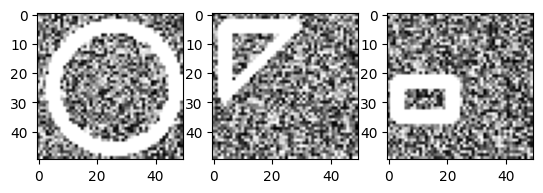

In [ ]:
plt.subplot(131)
plt.imshow(ring, cmap='gray')
plt.subplot(132)
plt.imshow(triangle, cmap='gray')
plt.subplot(133)
plt.imshow(rectangle, cmap='gray')
plt.show()

## 4. CL 训练流程

### 4.1 Stage 1：Base Task（ring）

**目标**：训练基础检测能力

- 类别数：1（ring）
- 模型初始化：YOLOv11-n
- 参数更新：全模型
- Epoch：300
- Classes: [ring]
- 输出权重：stage1_best.pt



### 4.1.1 训练代码

In [ ]:
import sys
sys.path.append("..")

from ultralytics import YOLO
# s 181 layers, 9,429,340 parameters, 9,429,324 gradients, 21.6 GFLOPs

# 加载一个预训练的 YOLO11n 模型
model = YOLO("/data/lijunlin/project/Detect/yolov11/CL/yolo11n-CL.yaml")

# 在 COCO8 数据集上训练模型 100 个周期
train_results = model.train(
    data         = "/data/lijunlin/project/Detect/yolov11/CL/data_stage1.yaml",  # 数据集配置文件路径
    epochs       = 300,  # 训练周期数
    imgsz        = 50,  # 训练图像尺寸
    device       = "cuda:0",  # 运行设备（例如 'cpu', 0, [0,1,2,3]）
    multi_scale  = True,
    close_mosaic = 10,
    amp          = True,
    fraction     = 1,
    profile      = True,
    batch        = 16,
    cutmix       = 0.2,
    mixup        = 0.2,
    mosaic       = 0.3,
    scale        = 1/3,
)

label = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train/val_batch0_labels.jpg")
pred = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train/val_batch0_pred.jpg")

New https://pypi.org/project/ultralytics/8.3.248 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.168 🚀 Python-3.9.23 torch-2.7.1+cu126 CUDA:0 (NVIDIA RTX A6000, 48669MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.2, data=/data/lijunlin/project/Detect/yolov11/CL/data_stage1.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=50, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/data/lijunlin/project/Detect/yolov11/CL/yolo11n-CL.yaml, momentum=0.937, mosaic=0.3

train: Scanning /data/lijunlin/project/Detect/yolov11/CL/data/stage1/labels/train... 50 images, 10 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<00:00, 1414.40it/s]

train: New cache created: /data/lijunlin/project/Detect/yolov11/CL/data/stage1/labels/train.cache


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 49.1±17.3 MB/s, size: 2.4 KB)


val: Scanning /data/lijunlin/project/Detect/yolov11/CL/data/stage1/labels/val... 10 images, 2 backgrounds, 0 corrupt: 100%|██████████| 10/10 [00:00<00:00, 1412.13it/s]

...

    300/300     0.322G     0.5024     0.4367     0.9577          1         96: 100%|██████████| 4/4 [00:00<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 16.96it/s]

                   all         10          8      0.993          1      0.995      0.885



300 epochs completed in 0.069 hours.
Optimizer stripped from runs/detect/train4/weights/last.pt, 5.4MB
Optimizer stripped from runs/detect/train4/weights/best.pt, 5.4MB

Validating runs/detect/train4/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.9.23 torch-2.7.1+cu126 CUDA:0 (NVIDIA RTX A6000, 48669MiB)
YOLO11n-CL summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 26.93it/s]


                   all         10          8      0.986          1      0.995      0.937
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/train4


### 4.1.2 训练结果

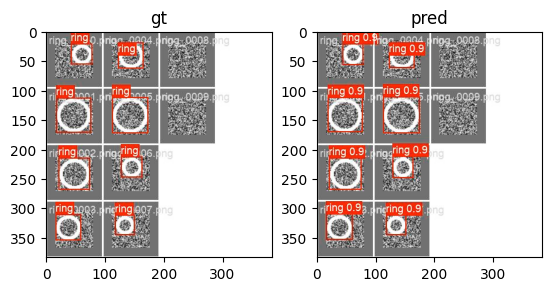

In [ ]:
plt.subplot(121)
plt.imshow( label, cmap="gray")
plt.title("gt")
plt.subplot(122)
plt.imshow( pred, cmap="gray")
plt.title("pred")
plt.show()


### 4.2 Stage 2：Increment 1（+ triangle）

**目标**：在保持 ring 性能的同时，引入 triangle

- 类别数：2（ring + triangle）
- 初始化权重：Stage1 best
- 数据组成：
  - 所有 triangle
  - ring replay（10%–30%）
- 参数更新策略：
  - Backbone：冻结
  - Neck + Detect Head：可训练
- Epoch：70
- Classes: [ring, triangle]
- 输出权重：stage2_best.pt

**CL 关键策略**：
- 禁用强数据增强（mosaic / mixup / cutmix）
- 小学习率（5e-4）
- 快速收敛 + Early stopping

### 4.2.1 训练代码

In [ ]:
# import sys
# sys.path.append("..")
# from ultralytics import YOLO
import time

start_time = time.time()
total_time = 0 
def on_train_start(trainer):
    global start_time 
    start_time = time.time() 
 
def on_train_end(trainer):
    global total_time
    total_time = time.time() - start_time
    print(f"Training completed in {total_time}, {total_time / 60:.2f} minutes")

# 加载一个预训练的 YOLO11n 模型
model = YOLO("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train/weights/best.pt")
for m in model.model.model[:-13]:
    for p in m.parameters():
        p.requires_grad = False

model.add_callback("on_train_start", on_train_end)  # 注册回调
model.add_callback("on_train_end", on_train_end)  # 注册回调

train_results = model.train(
    data         = "/data/lijunlin/project/Detect/yolov11/CL/data_stage2.yaml",  # 数据集配置文件路径
    epochs       = 70,
    imgsz        = 64,
    device       = "cuda:0",
    batch        = 16,
    lr0          = 1e-1,          
    close_mosaic = 0,
    amp          = True,
    mosaic       = 0.0,         
    mixup        = 0.0,
    cutmix       = 0.0,
)
print(model.info())

label = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train2/val_batch0_labels.jpg")
pred = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train2/val_batch0_pred.jpg")


New https://pypi.org/project/ultralytics/8.3.248 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.168 🚀 Python-3.9.23 torch-2.7.1+cu126 CUDA:0 (NVIDIA RTX A6000, 48669MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/data/lijunlin/project/Detect/yolov11/CL/data_stage2.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.1, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train/weights/best.pt, momentum=

train: Scanning /data/lijunlin/project/Detect/yolov11/CL/data/stage2/labels/train.cache... 20 images, 2 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 110.6±38.3 MB/s, size: 2.5 KB)


val: Scanning /data/lijunlin/project/Detect/yolov11/CL/data/stage2/labels/val.cache... 4 images, 1 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]


Plotting labels to runs/detect/train6/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.1' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Training completed in 5.213524341583252, 0.09 minutes
Image sizes 64 train, 64 val
Using 8 dataloader workers
Logging results to runs/detect/train6
Starting training for 70 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      70/70     0.395G      1.183      1.294      1.076          4         64: 100%|██████████| 2/2 [00:00<00:00,  8.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 32.04it/s]

                   all          4          3      0.933      0.936      0.995      0.709



70 epochs completed in 0.013 hours.
Optimizer stripped from runs/detect/train6/weights/last.pt, 5.4MB
Optimizer stripped from runs/detect/train6/weights/best.pt, 5.4MB

Validating runs/detect/train6/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.9.23 torch-2.7.1+cu126 CUDA:0 (NVIDIA RTX A6000, 48669MiB)
YOLO11n-CL summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 41.04it/s]


                   all          4          3      0.933      0.936      0.995      0.709
                  ring          1          1      0.865          1      0.995      0.697
              triangle          2          2          1      0.871      0.995      0.722
Speed: 0.1ms preprocess, 3.0ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/train6
Training completed in 54.0542938709259, 0.90 minutes
YOLO11n-CL summary: 181 layers, 2,590,230 parameters, 0 gradients, 6.4 GFLOPs
(181, 2590230, 0, 6.4416768)


### 4.2.2 训练结果

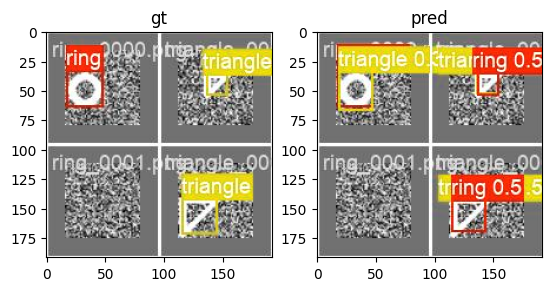

训练时间： 54.0542938709259  seconds


In [ ]:

label = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train2/val_batch0_labels.jpg")
pred = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train2/val_batch0_pred.jpg")
plt.subplot(121)
plt.imshow( label, cmap="gray")
plt.title("gt")
plt.subplot(122)
plt.imshow( pred, cmap="gray")
plt.title("pred")
plt.show()

print("训练时间：", total_time, " seconds")





### 4.3 Stage 3：Increment 2（+ rectangle）

**目标**：继续扩展类别，同时最小化累计遗忘

- 类别数：3（ring + triangle + rectangle）
- 初始化权重：Stage2 best
- 数据组成：
  - 所有 rectangle
  - ring + triangle replay（各 10%–15%）
- 参数更新策略：
  - Backbone：冻结
  - Neck：部分解冻
  - Detect Head：全训练
- Epoch：10–15
- Classes: [ring, triangle, rectangle]
- 输出权重：stage3_best.pt

### 4.3.1 训练代码

In [ ]:
import time

start_time = time.time()
total_time = 0 
def on_train_start(trainer):
    global start_time 
    start_time = time.time() 
 
def on_train_end(trainer):
    global total_time
    total_time = time.time() - start_time
    print(f"Training completed in {total_time}, {total_time / 60:.2f} minutes")

# 加载一个预训练的 YOLO11n 模型
model = YOLO("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train2/weights/best.pt")
for m in model.model.model[:-13]:
    for p in m.parameters():
        p.requires_grad = False

model.add_callback("on_train_start", on_train_end)  # 注册回调
model.add_callback("on_train_end", on_train_end)  # 注册回调

train_results = model.train(
    data         = "/data/lijunlin/project/Detect/yolov11/CL/data_stage3.yaml",  # 数据集配置文件路径
    epochs       = 70,
    imgsz        = 64,
    device       = "cuda:0",
    batch        = 32,
    lr0          = 1e-1,          
    close_mosaic = 0,
    amp          = True,
    mosaic       = 0.0,         
    mixup        = 0.0,
    cutmix       = 0.0,
)
print(model.info())

### 4.3.3 训练结果

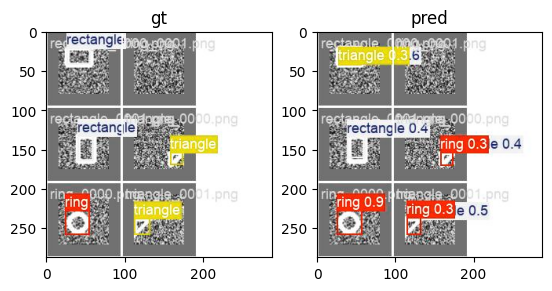

训练时间： 54.0542938709259  seconds


In [22]:
label = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train3/val_batch0_labels.jpg")
pred = cv2.imread("/data/lijunlin/project/Detect/yolov11/CL/runs/detect/train3/val_batch0_pred.jpg")

plt.subplot(121)
plt.imshow( label, cmap="gray")
plt.title("gt")
plt.subplot(122)
plt.imshow( pred, cmap="gray")
plt.title("pred")
plt.show()

print("训练时间：", total_time, " seconds")